# 🏥 Análisis Exploratorio de Datos: Readmisión Hospitalaria en Pacientes Diabéticos
**Universidad Industrial de Santander — Inteligencia Artificial I | 2026-1 | Grupo C2**

---

## 1. Problema y Datos

**Contexto:** El dataset *Diabetes 130-US Hospitals (1999–2008)* contiene **101,766 registros** de hospitalizaciones de pacientes diabéticos en 130 hospitales de EE.UU. durante 10 años. Cada registro corresponde a un encuentro clínico con información demográfica, diagnóstica, de tratamiento y de seguimiento.

**Problema a resolver:** Predecir si un paciente será **readmitido dentro de los próximos 30 días** tras el alta hospitalaria (`readmitted = <30`). Los reingresos tempranos indican complicaciones o fallos en el tratamiento inicial y representan un alto costo tanto clínico como económico.

**Desafíos del dataset:**
- **Desbalance de clases:** La categoría `<30` (reingreso temprano) es minoría frente a `NO` y `>30`.
- **Valores faltantes:** Variables como `weight`, `payer_code` y `medical_specialty` tienen >50% de datos ausentes.
- **Alta dimensionalidad:** 50 variables originales, muchas de medicamentos con baja varianza.
- **Registros no válidos:** Pacientes fallecidos o enviados a hospicios no pueden ser readmitidos y sesgan el análisis.

---

## 2. Justificación de la Inteligencia Artificial

Un modelo de Machine Learning es **superior al análisis estadístico tradicional** para este problema porque:

1. **Interacciones no lineales:** La combinación de múltiples medicamentos, diagnósticos y días de hospitalización crea patrones complejos que una regresión simple no captura.
2. **Alta dimensionalidad:** Con ~30 variables relevantes, los algoritmos como Random Forest identifican automáticamente las más importantes.
3. **Generalización:** Un modelo entrenado puede aplicarse en tiempo real al momento del alta para identificar pacientes de alto riesgo y activar protocolos preventivos.
4. **Impacto clínico concreto:** Reducir readmisiones tempranas mejora la calidad de vida del paciente y reduce costos hospitalarios.

---

## 3. Variable Objetivo

`readmitted`: Variable categórica tricotómica que indica si el paciente fue readmitido y en qué tiempo:
- **`NO`** → No fue readmitido (clase mayoritaria)
- **`<30`** → Reingresó dentro de 30 días ⚠️ **(clase de interés — ALTO RIESGO)**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import skew
import warnings
warnings.filterwarnings('ignore')

# Estilo global
sns.set_theme(style='darkgrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

PALETTE_OBJ = {'NO': '#2ecc71', '>30': '#f39c12', '<30': '#e74c3c'}
print("✅ Librerías cargadas correctamente")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df_raw = pd.read_csv('/content/drive/MyDrive/Proyecto IA/diabetic_data.csv', na_values='?')

# Filtrar la categoría '>30' desde el inicio para trabajar solo con clasificación binaria
df_raw = df_raw[df_raw['readmitted'] != '>30'].copy()

print(f"✅ Dataset cargado y filtrado (sin '>30'): {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head(3)

---
## 4. Calidad de Datos y Preprocesamiento

Antes de analizar, debemos limpiar el dataset aplicando tres pasos:
1. **Mapeo de IDs numéricos** a etiquetas legibles usando `IDS_mapping.csv`
2. **Filtrado crítico** de registros no readmitibles (fallecidos, hospicios)
3. **Gestión de valores nulos** — eliminación de columnas con >50% faltantes


In [ ]:
# ── Mapeo desde IDS_mapping.csv ──────────────────────────────────────────
admission_map = {1:'Emergency',2:'Urgent',3:'Elective',4:'Newborn',
                 5:'Not Available',7:'Trauma Center',8:'Not Mapped'}

discharge_map = {1:'Home',2:'Short-term Hospital',3:'SNF',4:'ICF',
                 5:'Other Inpatient',6:'Home+Health Service',7:'Left AMA',
                 8:'Home IV Provider',9:'Admitted Inpatient',10:'Neonatal Transfer',
                 11:'Expired',12:'Still Patient',13:'Hospice/Home',
                 14:'Hospice/Facility',15:'Medicare Swing Bed',
                 16:'Outpatient Ref (other)',17:'Outpatient Ref (this)',
                 19:'Expired@Home',20:'Expired@Facility',21:'Expired Unknown',
                 22:'Rehab Facility',23:'Long-term Care',24:'Medicaid Nursing',
                 25:'Not Mapped',26:'Unknown'}

admission_src_map = {1:'Physician Referral',2:'Clinic Referral',3:'HMO Referral',
                     4:'Transfer Hospital',5:'Transfer SNF',6:'Transfer Other',
                     7:'Emergency Room',8:'Court/Law',9:'Not Available'}

df = df_raw.copy()
df['admission_type_label']        = df['admission_type_id'].map(admission_map)
df['discharge_disposition_label'] = df['discharge_disposition_id'].map(discharge_map)
df['admission_source_label']      = df['admission_source_id'].map(admission_src_map)

print("✅ IDs mapeados a etiquetas legibles")
print(df[['admission_type_id','admission_type_label',
          'discharge_disposition_id','discharge_disposition_label']].head(4).to_string())

# ── Filtrado crítico ─────────────────────────────────────────────────────
# Pacientes fallecidos o en hospicio NO pueden ser readmitidos → los eliminamos
IDS_EXCLUIR = [11, 13, 14, 19, 20, 21]
antes = len(df)
df = df[~df['discharge_disposition_id'].isin(IDS_EXCLUIR)].copy()
print(f"\n✅ Filtrado crítico: {antes - len(df):,} registros eliminados (fallecidos/hospicios)")
print(f"📊 Dataset limpio: {len(df):,} registros")


In [ ]:
# ── Análisis de valores nulos ────────────────────────────────────────────
nulos     = df.isnull().sum()
nulos_pct = nulos / len(df) * 100
nulos_df  = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
nulos_df  = nulos_df[nulos_df['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)

print("📋 Columnas con valores faltantes:\n")
cols_eliminar = []
for col, row in nulos_df.iterrows():
    if row['Porcentaje (%)'] > 50:
        decision = "❌ ELIMINAR (>50% nulos)"
        cols_eliminar.append(col)
    else:
        decision = "⚠️  Mantener / Imputar"
    print(f"  {col:35s}: {row['Porcentaje (%)']:5.1f}%  →  {decision}")

# Eliminar columnas con >50% nulos
df.drop(columns=cols_eliminar, inplace=True)
print(f"\n✅ Columnas eliminadas: {cols_eliminar}")
print(f"📊 Dataset final: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.tail()

---
## 5. Variable Objetivo: `readmitted`

Analizar la distribución de la variable objetivo es el primer paso del EDA.
Nos permite entender el **desbalance de clases** y establecer la línea base del problema.


📊 DISTRIBUCIÓN DE READMITTED (binaria):

    NO: 52,527 pacientes  ( 82.3%)  █████████████████████████████████████████
   <30: 11,314 pacientes  ( 17.7%)  ████████


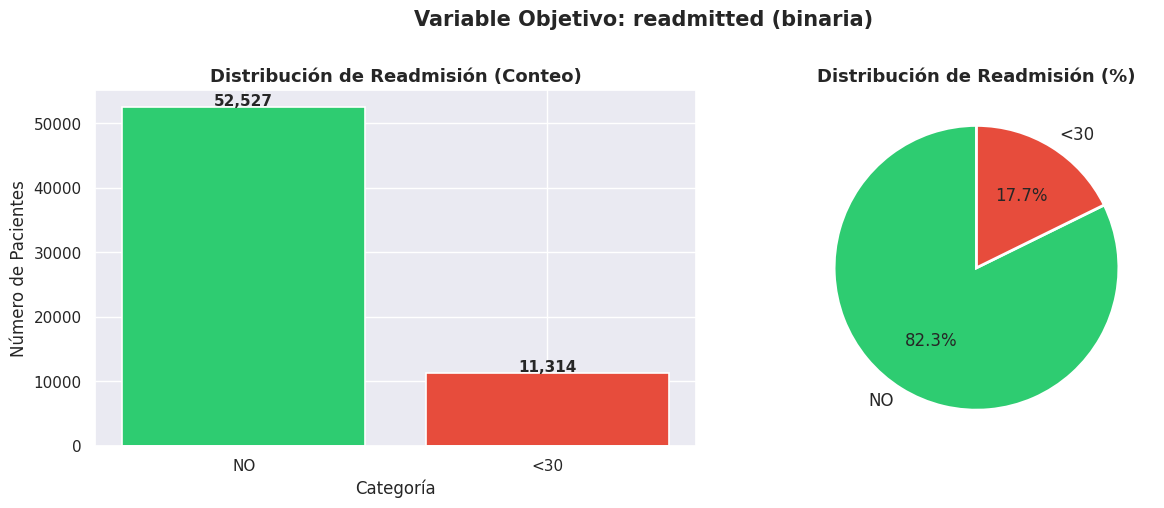


⚠️  DESBALANCE: La clase '<30' (alto riesgo) representa solo el 17.7% de los datos.
   Esto deberá tratarse con SMOTE o undersampling en la fase de modelado.


In [28]:
# Transform the 'readmitted' variable into a binary target as requested by the user
# 'NO' and '>30' will be mapped to 'NO', while '<30' remains '<30'.
readmitted_map_binary = {
    'NO': 'NO',
    '>30': 'NO',
    '<30': '<30'
}
df['readmitted'] = df['readmitted'].map(readmitted_map_binary)

counts = df['readmitted'].value_counts()
pct    = df['readmitted'].value_counts(normalize=True) * 100

print("📊 DISTRIBUCIÓN DE READMITTED (binaria):\n")
for cat in counts.index:
    bar = '█' * int(pct[cat] / 2)
    print(f"  {cat:>4s}: {counts[cat]:>6,} pacientes  ({pct[cat]:5.1f}%)  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras
colores = [PALETTE_OBJ[c] for c in counts.index]
bars = axes[0].bar(counts.index, counts.values, color=colores, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribución de Readmisión (Conteo)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Categoría'); axes[0].set_ylabel('Número de Pacientes')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+200, f'{v:,}', ha='center', fontweight='bold')

# Pastel
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colores, startangle=90, textprops={'fontsize':12},
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Distribución de Readmisión (%)', fontsize=13, fontweight='bold')

plt.suptitle('Variable Objetivo: readmitted (binaria)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print(f"\n⚠️  DESBALANCE: La clase '<30' (alto riesgo) representa solo el {pct.get('<30',0):.1f}% de los datos.")
print("   Esto deberá tratarse con SMOTE o undersampling en la fase de modelado.")

---
## 6. Análisis Univariado — Variables Numéricas

**Regla del estándar mínimo del EDA:**
- Si la distribución es **simétrica** (|skewness| < 0.5) → reportar **Media ± Desviación Estándar**
- Si la distribución es **asimétrica o con outliers** (|skewness| ≥ 0.5) → reportar **Mediana + Rango IQR**

Para cada variable se presenta un **histograma** (forma de la distribución) y un **boxplot** (detección de outliers).


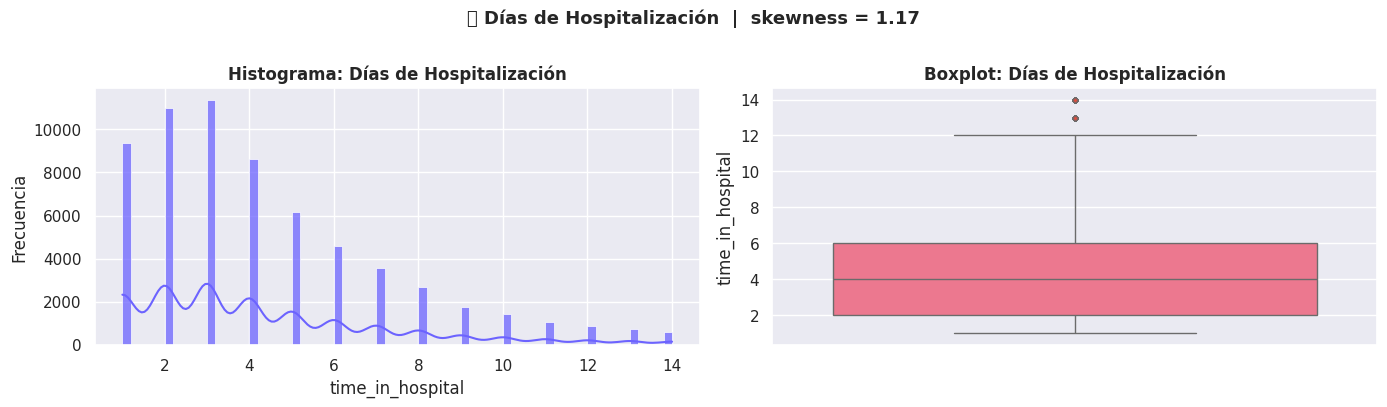

  ⚠️  Distribución ASIMÉTRICA hacia la derecha (positivo)
     Mediana = 4.0  |  IQR = [2.0 – 6.0]  |  Outliers detectados
------------------------------------------------------------


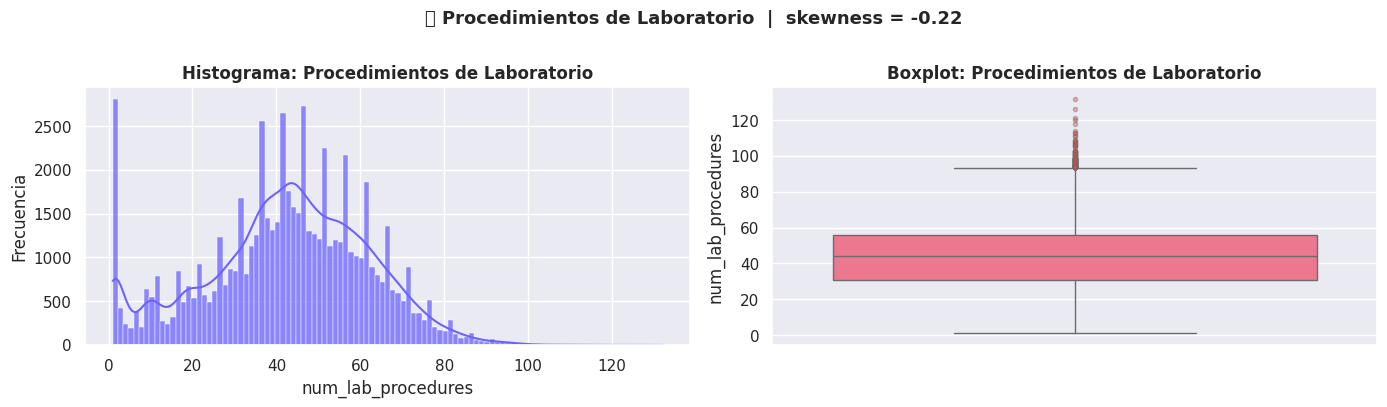

  ✅ Distribución SIMÉTRICA  →  Media = 42.39  |  Desv. Est. = 19.62
------------------------------------------------------------


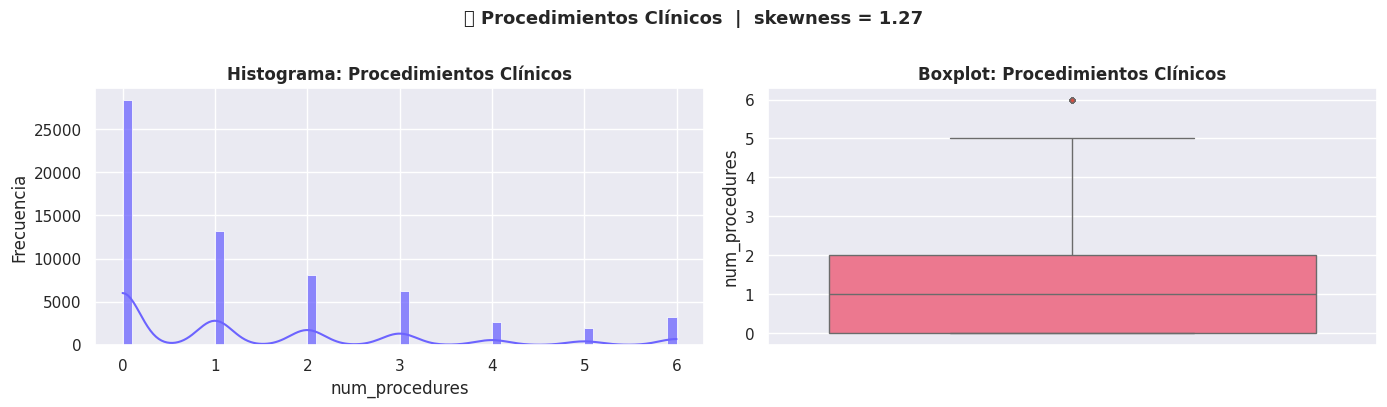

  ⚠️  Distribución ASIMÉTRICA hacia la derecha (positivo)
     Mediana = 1.0  |  IQR = [0.0 – 2.0]  |  Outliers detectados
------------------------------------------------------------


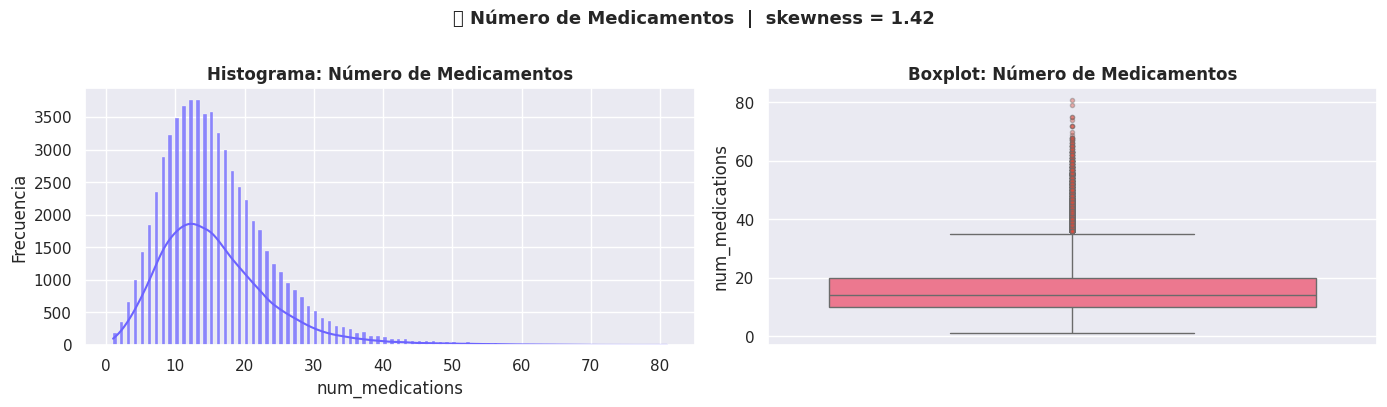

  ⚠️  Distribución ASIMÉTRICA hacia la derecha (positivo)
     Mediana = 14.0  |  IQR = [10.0 – 20.0]  |  Outliers detectados
------------------------------------------------------------


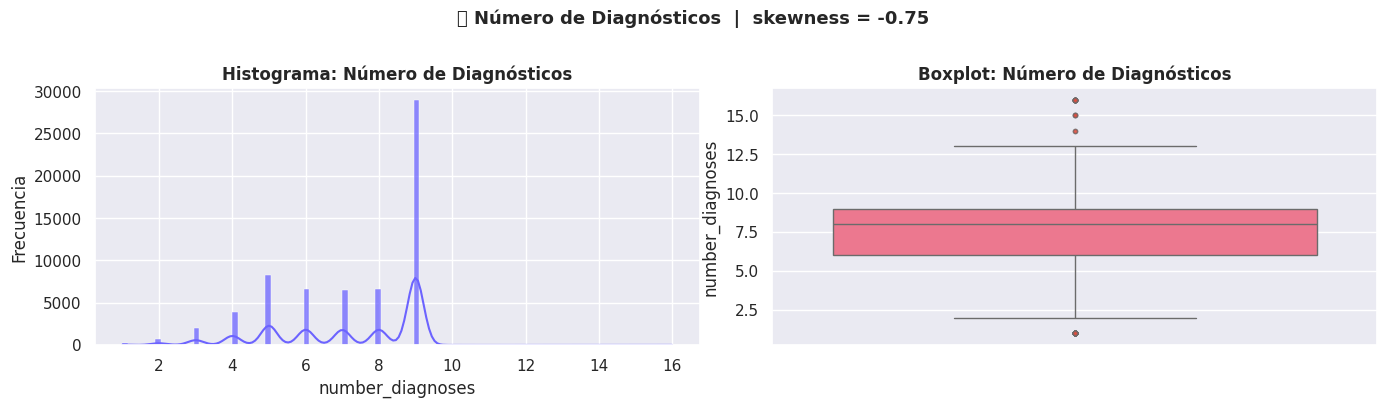

  ⚠️  Distribución ASIMÉTRICA hacia la izquierda (negativo)
     Mediana = 8.0  |  IQR = [6.0 – 9.0]  |  Outliers detectados
------------------------------------------------------------


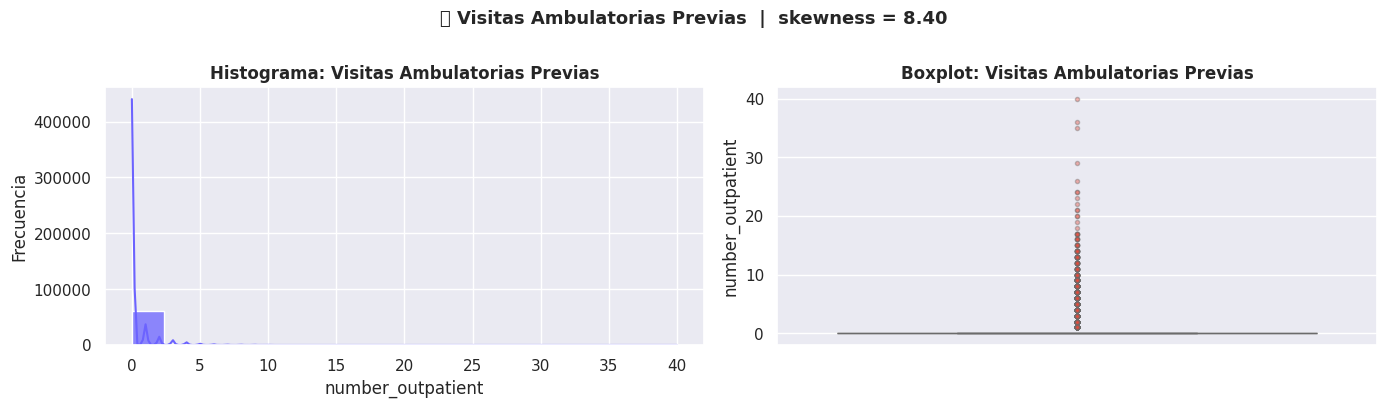

  ⚠️  Distribución ASIMÉTRICA hacia la derecha (positivo)
     Mediana = 0.0  |  IQR = [0.0 – 0.0]  |  Outliers detectados
------------------------------------------------------------


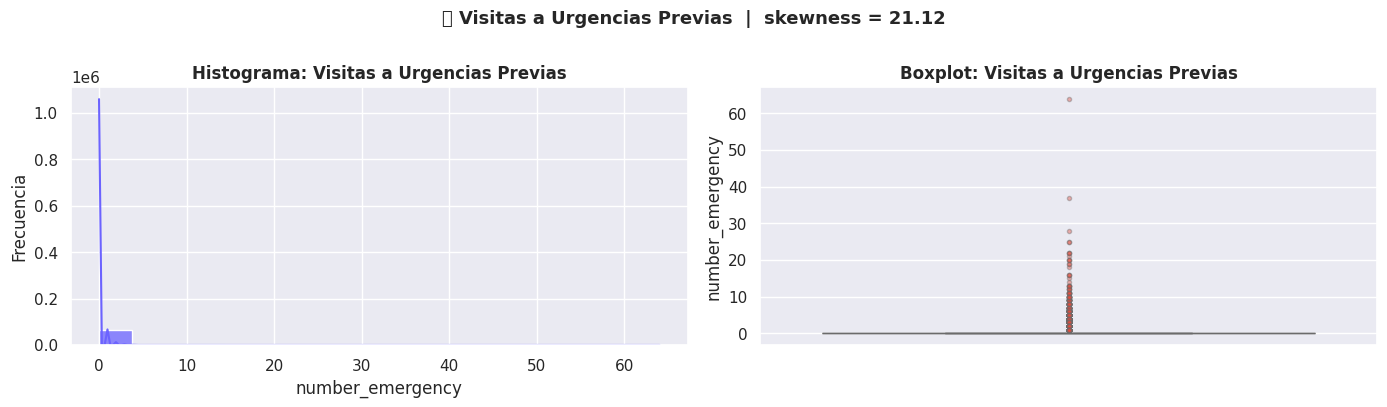

  ⚠️  Distribución ASIMÉTRICA hacia la derecha (positivo)
     Mediana = 0.0  |  IQR = [0.0 – 0.0]  |  Outliers detectados
------------------------------------------------------------


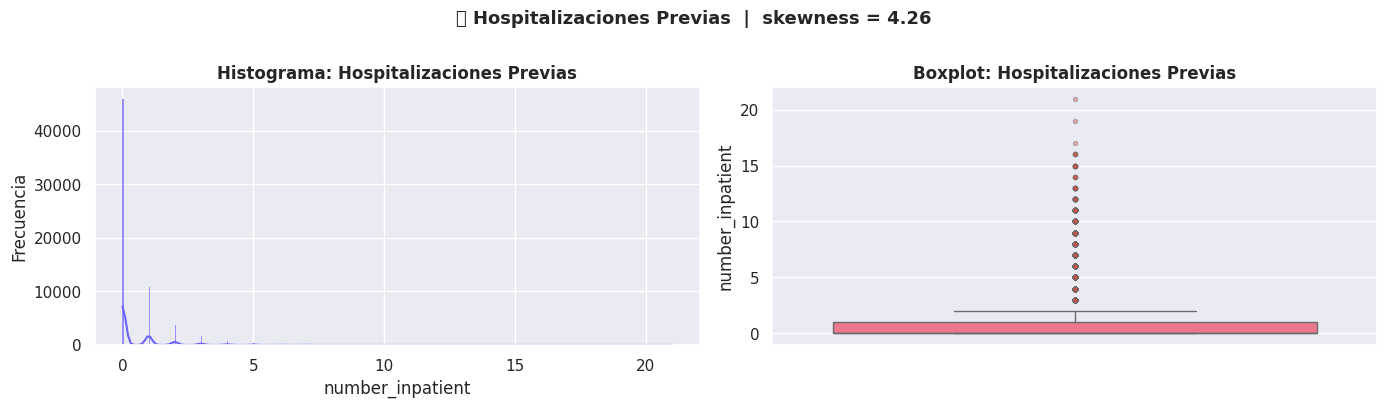

  ⚠️  Distribución ASIMÉTRICA hacia la derecha (positivo)
     Mediana = 0.0  |  IQR = [0.0 – 1.0]  |  Outliers detectados
------------------------------------------------------------


In [29]:
vars_numericas = {
    'time_in_hospital':    'Días de Hospitalización',
    'num_lab_procedures':  'Procedimientos de Laboratorio',
    'num_procedures':      'Procedimientos Clínicos',
    'num_medications':     'Número de Medicamentos',
    'number_diagnoses':    'Número de Diagnósticos',
    'number_outpatient':   'Visitas Ambulatorias Previas',
    'number_emergency':    'Visitas a Urgencias Previas',
    'number_inpatient':    'Hospitalizaciones Previas',
}

for var, titulo in vars_numericas.items():
    data = df[var].dropna()
    sk   = skew(data)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Histograma
    sns.histplot(data, kde=True, ax=axes[0], color='#6C63FF', alpha=0.75)
    axes[0].set_title(f'Histograma: {titulo}', fontweight='bold')
    axes[0].set_xlabel(var); axes[0].set_ylabel('Frecuencia')

    # Boxplot
    sns.boxplot(y=data, ax=axes[1], color='#FF6584',
                flierprops={'marker':'o','markersize':3,'alpha':0.4,'markerfacecolor':'#e74c3c'})
    axes[1].set_title(f'Boxplot: {titulo}', fontweight='bold')
    axes[1].set_ylabel(var)

    plt.suptitle(f'📊 {titulo}  |  skewness = {sk:.2f}', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()

    # Estadístico correcto según la forma
    if abs(sk) < 0.5:
        print(f"  ✅ Distribución SIMÉTRICA  →  Media = {data.mean():.2f}  |  Desv. Est. = {data.std():.2f}")
    else:
        q1, q3 = data.quantile(0.25), data.quantile(0.75)
        tipo = "derecha (positivo)" if sk > 0 else "izquierda (negativo)"
        print(f"  ⚠️  Distribución ASIMÉTRICA hacia la {tipo}")
        print(f"     Mediana = {data.median():.1f}  |  IQR = [{q1:.1f} – {q3:.1f}]  |  Outliers detectados")
    print("-" * 60)


---
## 7. Análisis Univariado — Variables Categóricas

Para variables categóricas se reporta la **frecuencia absoluta (conteo)** y el **porcentaje (%)** de cada categoría, acompañados de un gráfico de barras o pastel según el número de categorías.



📊 RAZA DEL PACIENTE:
   Caucasian                               : 48,818 ( 76.5%)
   AfricanAmerican                         : 12,154 ( 19.0%)
   Hispanic                                :  1,376 (  2.2%)
   Other                                   :  1,026 (  1.6%)
   Asian                                   :    467 (  0.7%)


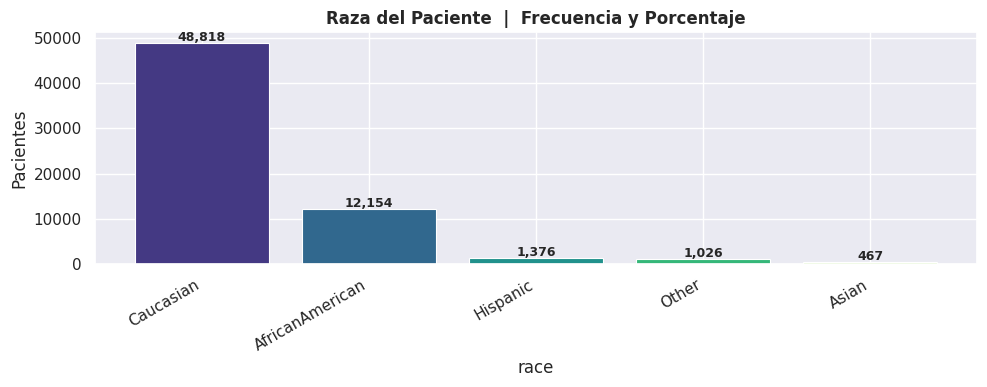

------------------------------------------------------------

📊 GÉNERO:
   Female                                  : 33,961 ( 53.2%)
   Male                                    : 29,877 ( 46.8%)
   Unknown/Invalid                         :      3 (  0.0%)


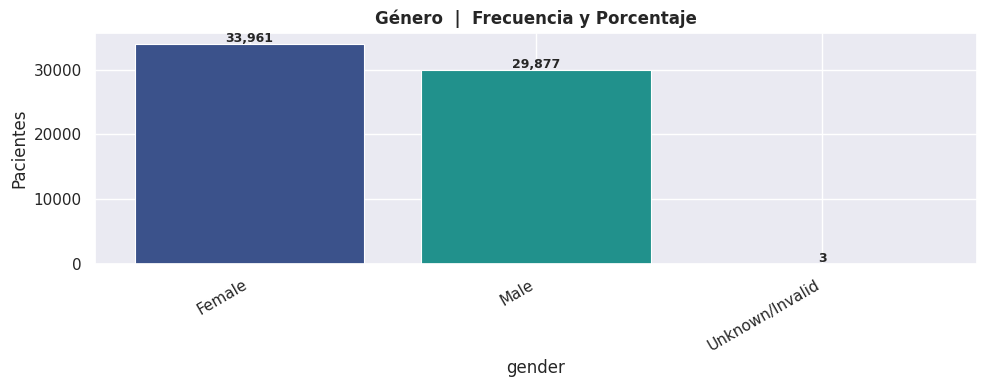

------------------------------------------------------------

📊 GRUPO DE EDAD:
   [70-80)                                 : 15,868 ( 24.9%)
   [60-70)                                 : 14,171 ( 22.2%)
   [50-60)                                 : 11,149 ( 17.5%)
   [80-90)                                 : 10,223 ( 16.0%)
   [40-50)                                 :  6,332 (  9.9%)
   [30-40)                                 :  2,577 (  4.0%)
   [90-100)                                :  1,782 (  2.8%)
   [20-30)                                 :  1,139 (  1.8%)
   [10-20)                                 :    466 (  0.7%)
   [0-10)                                  :    134 (  0.2%)


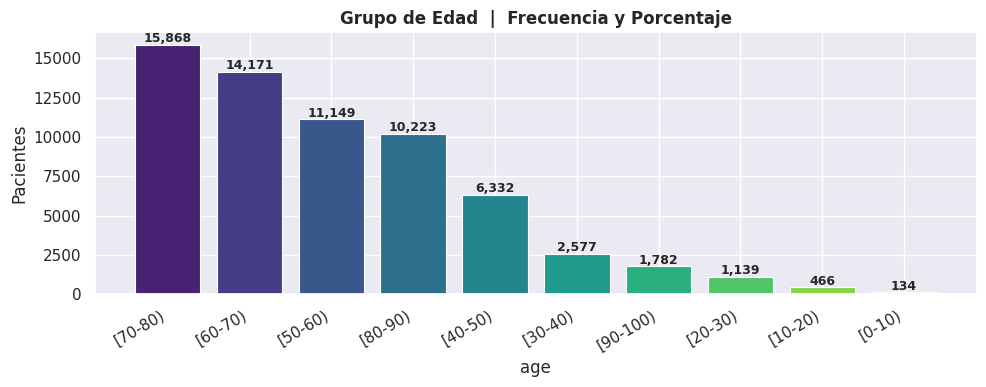

------------------------------------------------------------

📊 TIPO DE ADMISIÓN:
   Emergency                               : 36,072 ( 56.5%)
   Elective                                : 12,927 ( 20.2%)
   Urgent                                  : 11,684 ( 18.3%)
   Not Available                           :  2,896 (  4.5%)
   Not Mapped                              :    236 (  0.4%)
   Trauma Center                           :     18 (  0.0%)
   Newborn                                 :      8 (  0.0%)


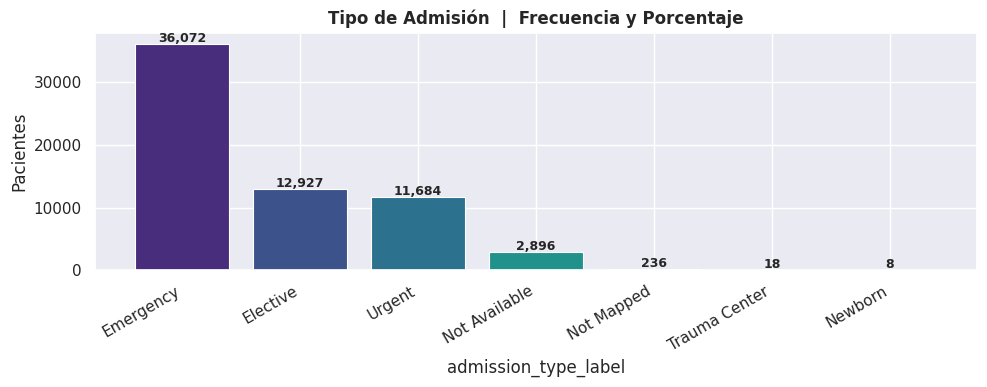

------------------------------------------------------------

📊 TIPO DE ALTA HOSPITALARIA:
   Home                                    : 41,490 ( 65.0%)
   SNF                                     :  9,038 ( 14.2%)
   Home+Health Service                     :  7,540 ( 11.8%)
   Rehab Facility                          :  1,474 (  2.3%)
   Short-term Hospital                     :  1,460 (  2.3%)
   Other Inpatient                         :    834 (  1.3%)
   Not Mapped                              :    613 (  1.0%)
   ICF                                     :    537 (  0.8%)
   Left AMA                                :    402 (  0.6%)
   Long-term Care                          :    268 (  0.4%)


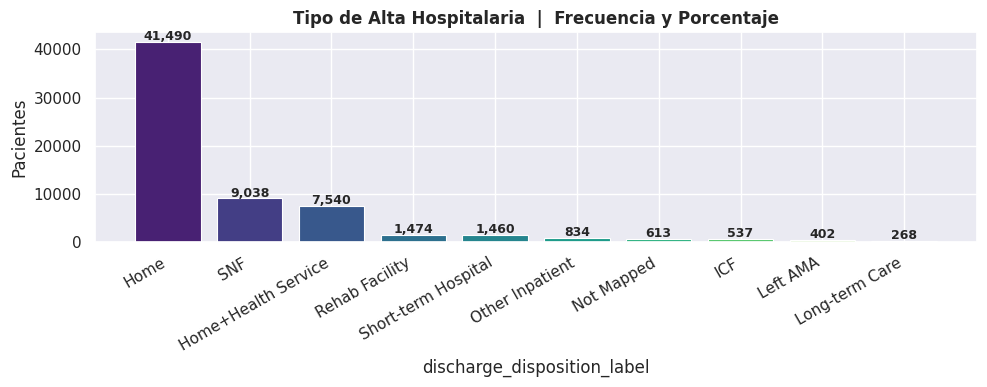

------------------------------------------------------------

📊 FUENTE DE ADMISIÓN:
   Emergency Room                          : 34,218 ( 53.6%)
   Physician Referral                      : 19,536 ( 30.6%)
   NaN/Faltante                            :  4,212 (  6.6%)
   Transfer Hospital                       :  2,446 (  3.8%)
   Transfer Other                          :  1,841 (  2.9%)
   Clinic Referral                         :    771 (  1.2%)
   Transfer SNF                            :    570 (  0.9%)
   HMO Referral                            :    127 (  0.2%)
   Not Available                           :    109 (  0.2%)
   Court/Law                               :     11 (  0.0%)


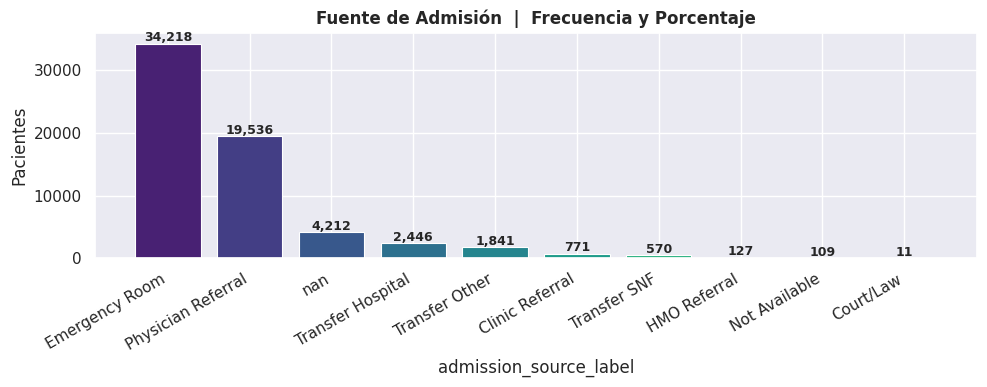

------------------------------------------------------------
⚠️  Columna 'A1Cresult' no encontrada, se omite.

📊 DOSIS DE INSULINA:
   No                                      : 30,443 ( 47.7%)
   Steady                                  : 19,601 ( 30.7%)
   Down                                    :  7,164 ( 11.2%)
   Up                                      :  6,633 ( 10.4%)


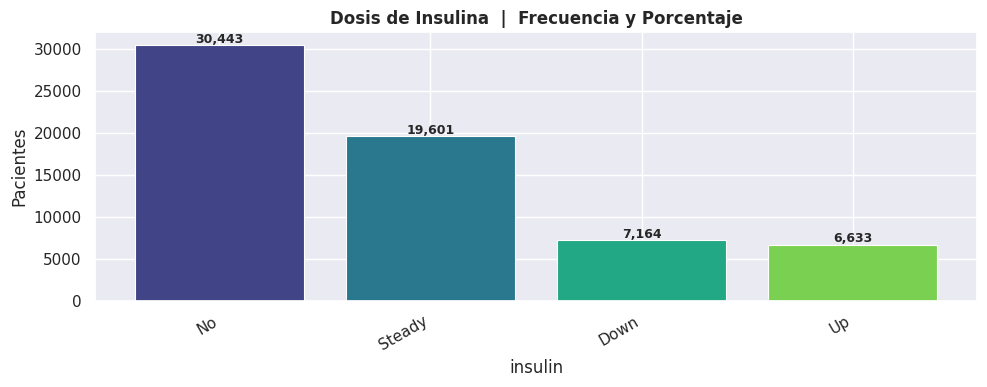

------------------------------------------------------------

📊 CAMBIO DE MEDICAMENTO:
   No                                      : 34,970 ( 54.8%)
   Ch                                      : 28,871 ( 45.2%)


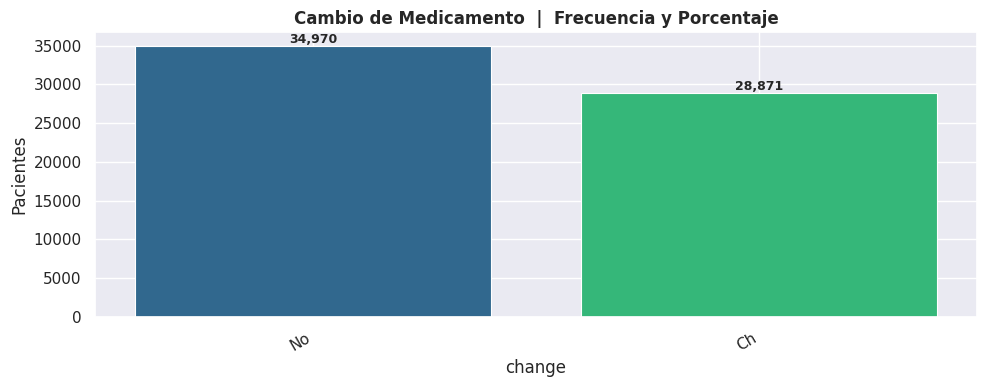

------------------------------------------------------------

📊 USO DE MEDICACIÓN PARA DIABETES:
   Yes                                     : 48,436 ( 75.9%)
   No                                      : 15,405 ( 24.1%)


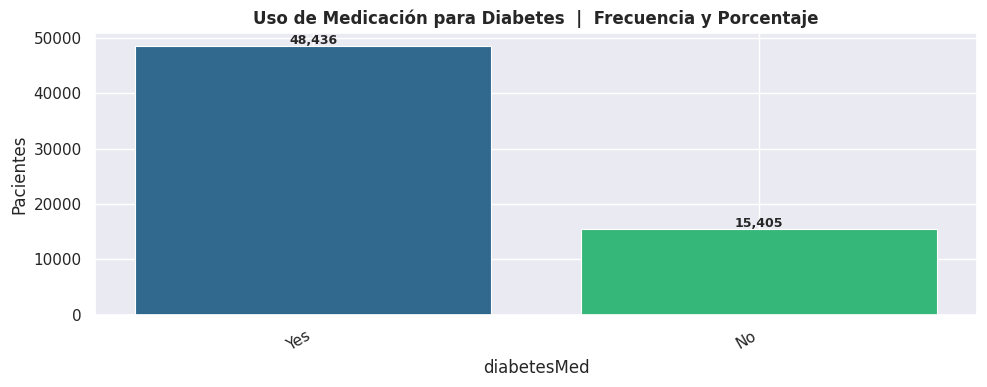

------------------------------------------------------------


In [30]:
vars_categoricas = {
    'race':                       'Raza del Paciente',
    'gender':                     'Género',
    'age':                        'Grupo de Edad',
    'admission_type_label':       'Tipo de Admisión',
    'discharge_disposition_label':'Tipo de Alta Hospitalaria',
    'admission_source_label':     'Fuente de Admisión',
    'A1Cresult':                  'Resultado Hemoglobina A1C',
    'insulin':                    'Dosis de Insulina',
    'change':                     'Cambio de Medicamento',
    'diabetesMed':                'Uso de Medicación para Diabetes',
}

for col, titulo in vars_categoricas.items():
    if col not in df.columns:
        print(f"⚠️  Columna '{col}' no encontrada, se omite.")
        continue

    counts = df[col].value_counts(dropna=False).head(10)
    pct    = df[col].value_counts(normalize=True, dropna=False) * 100

    print(f"\n📊 {titulo.upper()}:")
    for cat in counts.index:
        label = str(cat) if pd.notna(cat) else 'NaN/Faltante'
        print(f"   {label:40s}: {counts[cat]:>6,} ({pct[cat]:5.1f}%)")

    fig, ax = plt.subplots(figsize=(10, 4))
    colores_bar = sns.color_palette('viridis', len(counts))
    bars = ax.bar([str(x) for x in counts.index], counts.values,
                  color=colores_bar, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, v + counts.values.max()*0.01,
                f'{v:,}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'{titulo}  |  Frecuencia y Porcentaje', fontsize=12, fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Pacientes')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout(); plt.show()
    print("-" * 60)


---
## 8. Análisis Bivariado — Patrones e Insights con la Variable Objetivo

En esta sección cruzamos las variables más relevantes contra `readmitted` para identificar factores asociados al reingreso temprano (`<30`).


In [31]:
# Definición de grupos de variables para el análisis
vars_numericas_list = ['time_in_hospital','num_lab_procedures','num_procedures',
                       'num_medications','number_diagnoses',
                       'number_outpatient','number_emergency','number_inpatient']

vars_tratamiento = ['A1Cresult','insulin','change','diabetesMed']
vars_paciente    = ['race','gender','age']

print("✅ Grupos de variables definidos")
print(f"  Numéricas  : {vars_numericas_list}")
print(f"  Tratamiento: {vars_tratamiento}")
print(f"  Paciente   : {vars_paciente}")


✅ Grupos de variables definidos
  Numéricas  : ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'number_outpatient', 'number_emergency', 'number_inpatient']
  Tratamiento: ['A1Cresult', 'insulin', 'change', 'diabetesMed']
  Paciente   : ['race', 'gender', 'age']


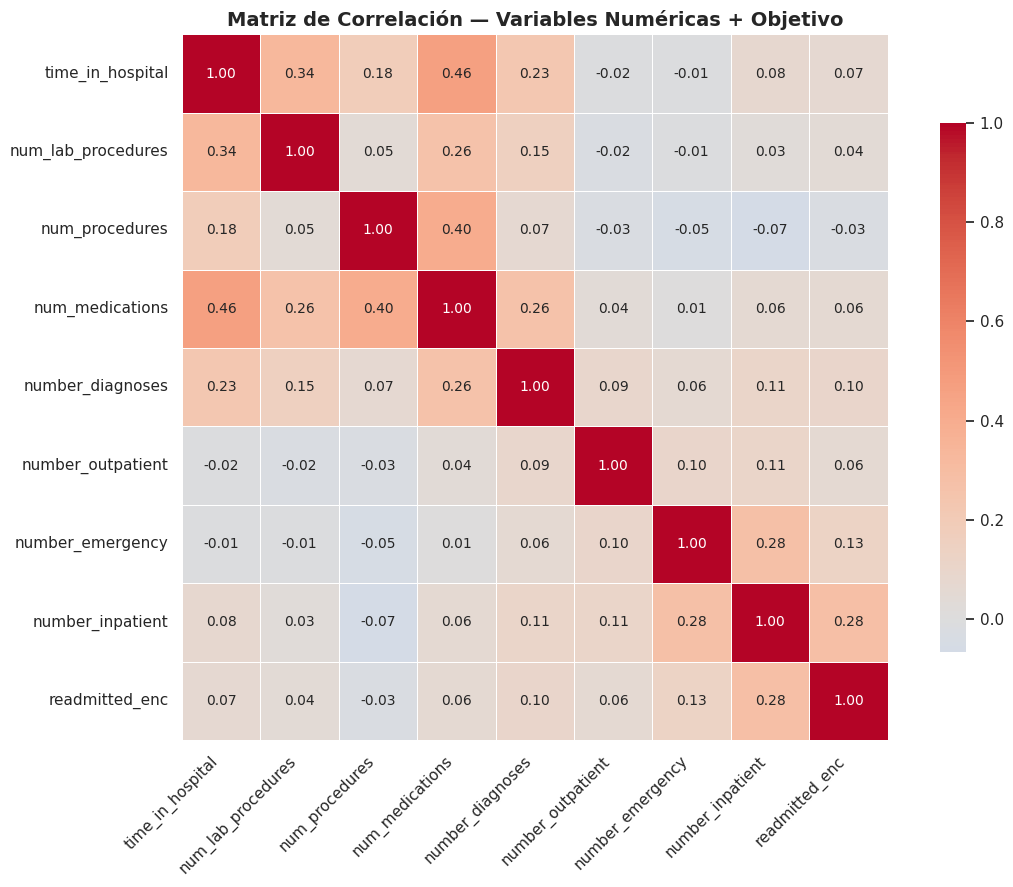


📈 TOP CORRELACIONES CON readmitted_enc:
  +0.282  →  number_inpatient
  +0.127  →  number_emergency
  +0.099  →  number_diagnoses
  +0.071  →  time_in_hospital
  +0.061  →  num_medications
  +0.060  →  number_outpatient
  +0.043  →  num_lab_procedures
  -0.027  →  num_procedures


In [32]:
# Codificar readmitted para correlación
df['readmitted_enc'] = df['readmitted'].map({'NO': 0, '>30': 1, '<30': 2})

numeric_df  = df[vars_numericas_list + ['readmitted_enc']]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink':0.75},
            annot_kws={'size':10})
plt.title('Matriz de Correlación — Variables Numéricas + Objetivo', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

# Top correlaciones con readmitted
print("\n📈 TOP CORRELACIONES CON readmitted_enc:")
corr_target = corr_matrix['readmitted_enc'].drop('readmitted_enc').abs().sort_values(ascending=False)
for var, val in corr_target.items():
    signo = '+' if corr_matrix.loc[var,'readmitted_enc'] >= 0 else '-'
    print(f"  {signo}{val:.3f}  →  {var}")


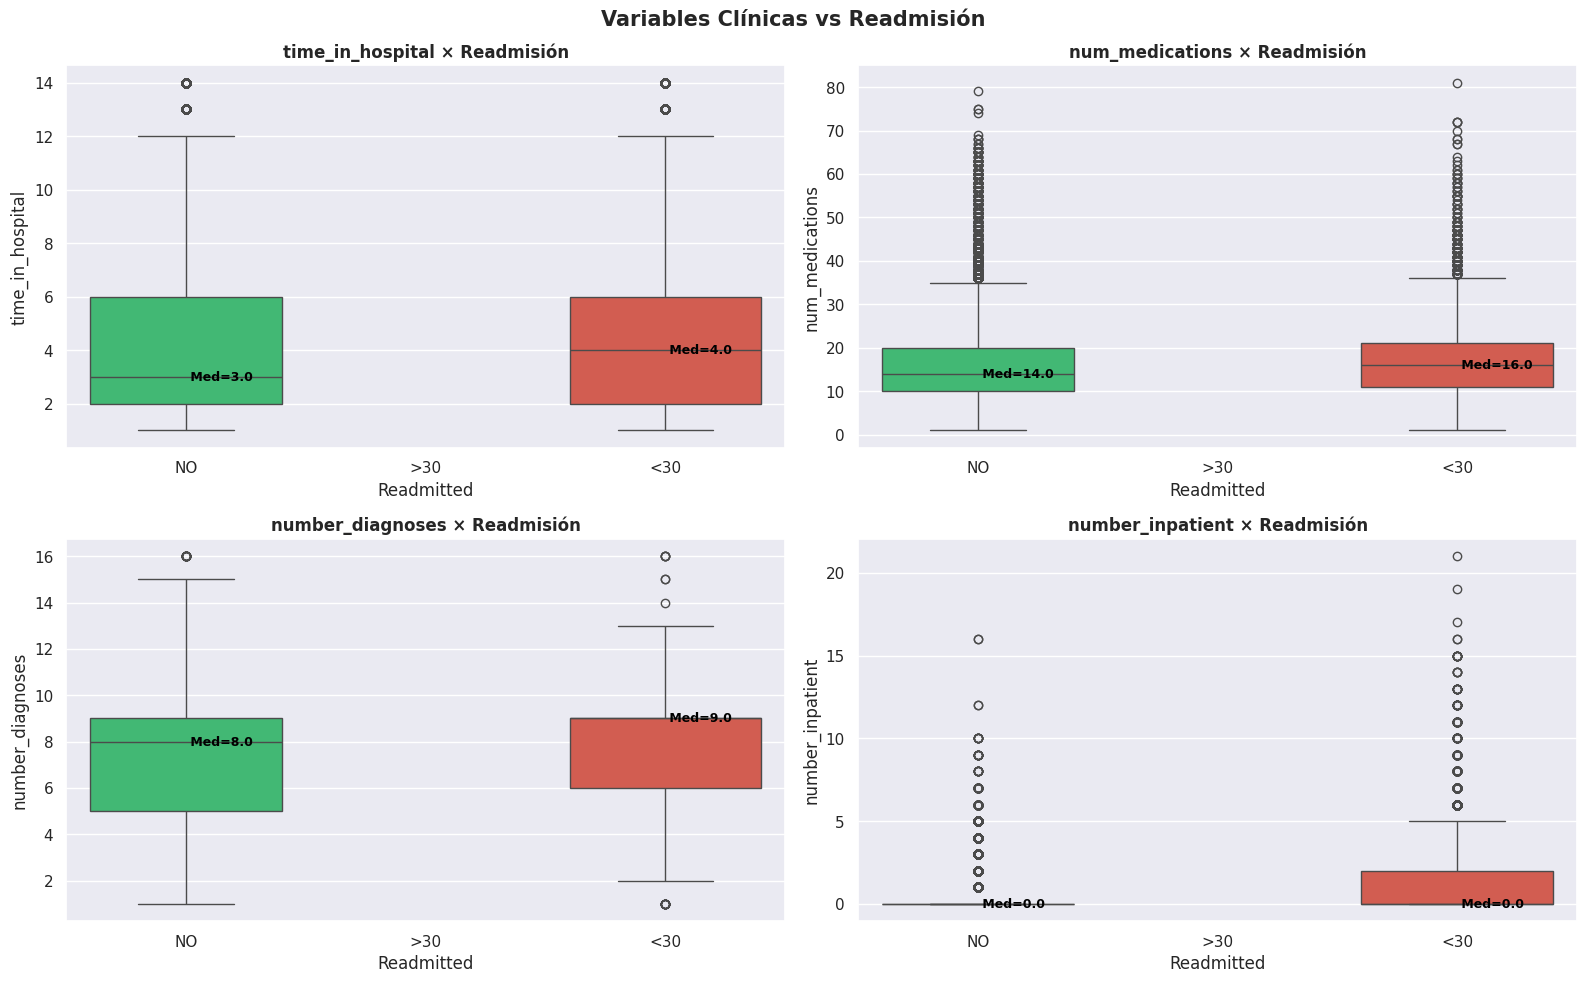

In [33]:
# ── Boxplot: variables clínicas × readmitted ────────────────────────────
vars_cruce = ['time_in_hospital','num_medications','number_diagnoses','number_inpatient']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

orden = ['NO', '>30', '<30']
colores_cruce = [PALETTE_OBJ[c] for c in orden]

for i, var in enumerate(vars_cruce):
    sns.boxplot(data=df, x='readmitted', y=var, order=orden,
                palette=PALETTE_OBJ, ax=axes[i])
    axes[i].set_title(f'{var} × Readmisión', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Readmitted')
    axes[i].set_ylabel(var)

    # Mediana por grupo
    medians = df.groupby('readmitted')[var].median()
    for j, cat in enumerate(orden):
        if cat in medians:
            axes[i].text(j, medians[cat], f' Med={medians[cat]:.1f}',
                         va='center', fontsize=9, color='black', fontweight='bold')

plt.suptitle('Variables Clínicas vs Readmisión', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


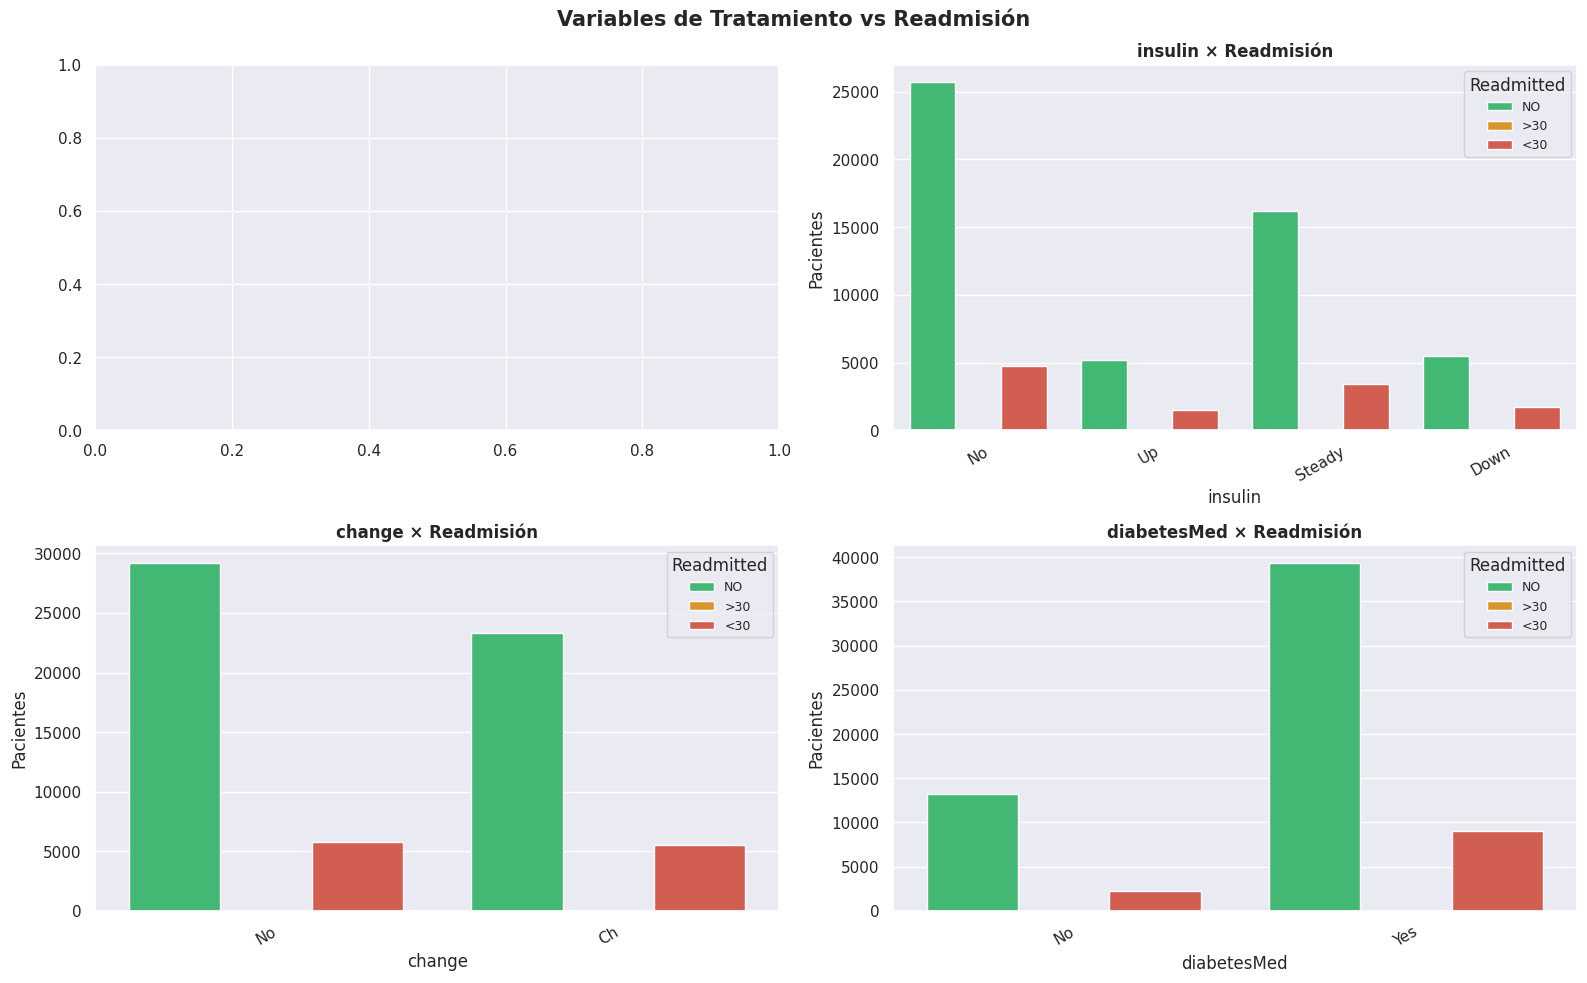

In [34]:
# ── Countplot: variables de tratamiento × readmitted ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(vars_tratamiento):
    if var not in df.columns:
        continue
    data_var = df[var].astype(str).str.strip().replace('nan','Faltante')
    temp = df.copy(); temp[var] = data_var

    sns.countplot(data=temp, x=var, hue='readmitted',
                  hue_order=['NO','>30','<30'], palette=PALETTE_OBJ,
                  ax=axes[i], edgecolor='white')
    axes[i].set_title(f'{var} × Readmisión', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(var); axes[i].set_ylabel('Pacientes')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Readmitted', fontsize=9)

plt.suptitle('Variables de Tratamiento vs Readmisión', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


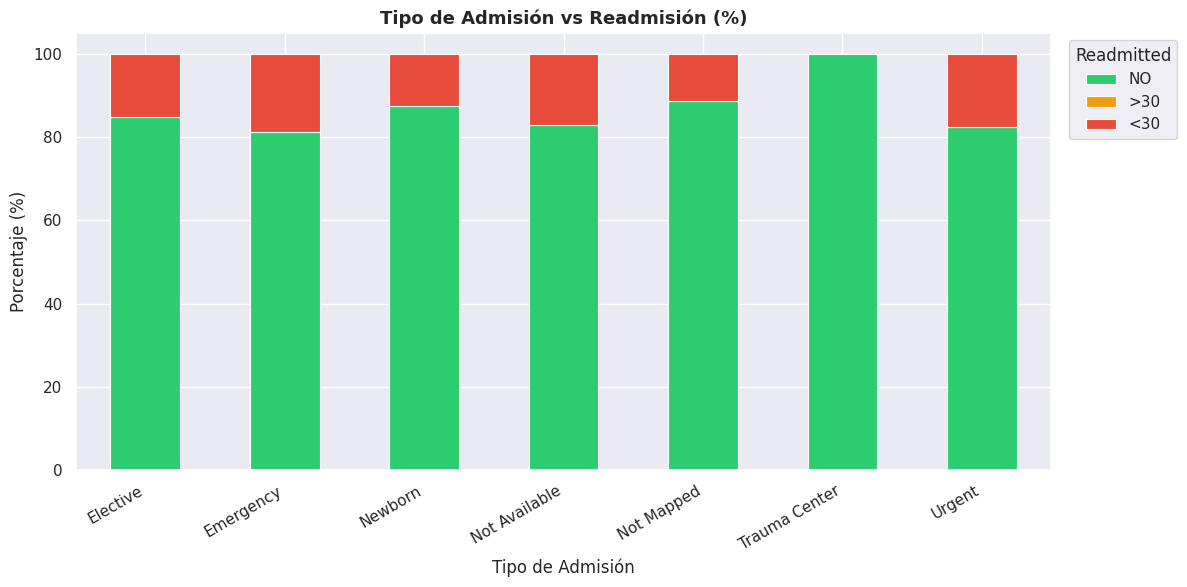


📋 Tabla de contingencia (%):
readmitted               NO  >30   <30
admission_type_label                  
Elective               84.9    0  15.1
Emergency              81.2    0  18.8
Newborn                87.5    0  12.5
Not Available          83.0    0  17.0
Not Mapped             88.6    0  11.4
Trauma Center         100.0    0   0.0
Urgent                 82.4    0  17.6


In [35]:
# ── Stacked bar: Tipo de Admisión × Readmisión ──────────────────────────
if 'admission_type_label' in df.columns:
    ct = pd.crosstab(df['admission_type_label'], df['readmitted'])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    # Reordenar columnas
    for col in ['NO','>30','<30']:
        if col not in ct_pct.columns:
            ct_pct[col] = 0
    ct_pct = ct_pct[['NO','>30','<30']]

    ax = ct_pct.plot(kind='bar', stacked=True, figsize=(12, 6),
                     color=[PALETTE_OBJ['NO'], PALETTE_OBJ['>30'], PALETTE_OBJ['<30']],
                     edgecolor='white', linewidth=0.8)
    plt.title('Tipo de Admisión vs Readmisión (%)', fontsize=13, fontweight='bold')
    plt.xlabel('Tipo de Admisión'); plt.ylabel('Porcentaje (%)')
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Readmitted', bbox_to_anchor=(1.01,1))
    plt.tight_layout(); plt.show()

    print("\n📋 Tabla de contingencia (%):")
    print(ct_pct.round(1).to_string())


---
---
# 📌 CORTE 2: Modelado y Optimización de Hiperparámetros

**Objetivo**: Entrenar y optimizar 4 modelos (Gaussian NB, Decision Tree, Random Forest, SVM) con búsqueda de hiperparámetros para predecir readmisión temprana (`<30`).



In [ ]:
# ── Imports adicionales para modelado ────────────────────────────────────
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      RandomizedSearchCV, StratifiedKFold)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                              recall_score, precision_score, roc_auc_score,
                              ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import time

print("✅ Librerías de modelado cargadas")

---
## 11. Preparación de Features — Codificación y Selección

Codificamos las variables categóricas según su naturaleza:
- **Ordinales** (`age`, `insulin`): OrdinalEncoder que respeta el orden natural
- **Binarias** (`change`, `diabetesMed`): LabelEncoder → {0, 1}
- **Nominales** (`race`, `gender`, labels de admisión/alta): OneHotEncoder

In [ ]:
# ── Codificación de variables ordinales y binarias ───────────────────────
age_map = {
    '[0-10)':0,'[10-20)':1,'[20-30)':2,'[30-40)':3,'[40-50)':4,
    '[50-60)':5,'[60-70)':6,'[70-80)':7,'[80-90)':8,'[90-100)':9
}
insulin_map = {'No':0, 'Steady':1, 'Up':2, 'Down':3}
# binary_map  = {'No':0, 'Yes':1, 'Ch':1}

change_map      = {'No':0, 'Ch':1}
binary_map      = {'No':0, 'Yes':1}



df['age_encoded']         = df['age'].map(age_map)
df['insulin_encoded']     = df['insulin'].map(insulin_map)
df['change_encoded']      = df['change'].map(change_map)
df['diabetesMed_encoded'] = df['diabetesMed'].map(binary_map)
# df['change_encoded']      = df['change'].map(binary_map)
# df['diabetesMed_encoded'] = df['diabetesMed'].map(binary_map)

# ── Definición de features ───────────────────────────────────────────────
numeric_features = [
    'time_in_hospital','num_lab_procedures','num_procedures',
    'num_medications','number_diagnoses',
    'number_outpatient','number_emergency','number_inpatient'
]
ordinal_binary_features = ['age_encoded','insulin_encoded','change_encoded','diabetesMed_encoded']
categorical_features    = ['gender','race','admission_type_label','discharge_disposition_label']
all_features = numeric_features + ordinal_binary_features + categorical_features
target = 'readmitted'

# Validar
missing = [f for f in all_features if f not in df.columns]
if missing:
    print(f"⚠️  Features faltantes: {missing}")
else:
    print(f"✅ {len(all_features)} features validadas")
    print(f"   Numéricas: {len(numeric_features)} | Ordinales/Binarias: {len(ordinal_binary_features)} | Categóricas: {len(categorical_features)}")

# Imputar nulos restantes
for col in numeric_features + ordinal_binary_features:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
for col in categorical_features:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f"✅ Nulos imputados (mediana para numéricas, moda para categóricas)")

## 12. Split Train/Test estratificado y Preprocessing

**Orden correcto**: Split PRIMERO con datos crudos, luego fit del scaler SOLO en train.
Esto garantiza que el StandardScaler no aprenda media/varianza del test set.

In [ ]:
# ── Preparar X e y con Split Estratificado ─────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# Aseguramos que usamos el dataframe 'df' y las listas de features definidas previamente
X = df[all_features].copy()
y = df[target].copy()

# 1. SPLIT ESTRATIFICADO (75/25)
# El parámetro 'stratify=y' garantiza que la distribución de la variable objetivo se mantenga
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. ColumnTransformer: fit SOLO en train para evitar data leakage
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric_scaler', StandardScaler(), numeric_features),
        ('ordinal_binary_identity', 'passthrough', ordinal_binary_features),
        ('nominal_onehot', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

# Ajustar preprocesador con train y transformar ambos sets
preprocessor.fit(X_train_raw)
X_train = preprocessor.transform(X_train_raw)
X_test  = preprocessor.transform(X_test_raw)

# Manejar NaN residuales
X_train = np.nan_to_num(X_train, nan=0.0)
X_test  = np.nan_to_num(X_test, nan=0.0)

# Reconstruir nombres de features tras One-Hot Encoding
ohe_names = list(preprocessor.named_transformers_['nominal_onehot']
                 .get_feature_names_out(categorical_features))
feature_names = numeric_features + ordinal_binary_features + ohe_names

print(f"✅ Split 75/25 ESTRATIFICADO completado")
print(f"   Train: {X_train.shape[0]:,} muestras")
print(f"   Test:  {X_test.shape[0]:,} muestras")
print(f"   Total features: {len(feature_names)}")

---
## 14. Configuración de Métricas y Validación Cruzada

**Métrica de optimización**: F1-macro — promedia F1 de las 3 clases con igual peso.
**Métrica clínica crítica**: Recall de `<30` — minimizar falsos negativos.
**Validación**: StratifiedKFold(5) dentro del GridSearch.

In [ ]:
scoring = {
    'f1_macro': 'f1_macro',
    'recall_macro': 'recall_macro',
    'precision_macro': 'precision_macro',
    'accuracy': 'accuracy'
}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("✅ Configuración de evaluación:")
print("   Scorer primario: F1-macro")
print("   Validación: StratifiedKFold(5)")
print("   Métricas secundarias: Recall-macro, Precision-macro, Accuracy")

---
## 15. Modelo 1: Gaussian Naive Bayes

NB asume independencia entre features y distribución gaussiana. Como nuestras variables (medicamentos, diagnósticos, días) claramente NO son independientes, este será el modelo más débil — sirve como **línea base** para comparar.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold
# Añadimos accuracy_score, confusion_matrix, ConfusionMatrixDisplay y matplotlib
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time
import numpy as np

print("="*80)
print("MODELO 1: GAUSSIAN NAIVE BAYES")
print("="*80)

scoring = {
    'f1_macro': 'f1_macro',
    'recall_macro': 'recall_macro',
    'precision_macro': 'precision_macro',
    'accuracy': 'accuracy'
}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_nb = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}

grid_nb = GridSearchCV(
    GaussianNB(), param_grid_nb, cv=cv_strategy,
    scoring=scoring, refit='f1_macro', n_jobs=-1, verbose=1
)

start = time.time()
grid_nb.fit(X_train, y_train)
t_nb = time.time() - start

X_test_processed_nb = preprocessor.transform(X_test_raw)
X_test_processed_nb = np.nan_to_num(X_test_processed_nb, nan=0.0)
y_test_for_nb = y.loc[X_test_raw.index]

y_pred_nb = grid_nb.predict(X_test_processed_nb)

# 1. Corrección del Accuracy real
acc_nb       = accuracy_score(y_test_for_nb, y_pred_nb)
f1_nb        = f1_score(y_test_for_nb, y_pred_nb, average='macro')
recall_cls   = recall_score(y_test_for_nb, y_pred_nb, average=None, labels=[0, 1])
recall_30_nb = recall_cls[1]
prec_cls     = precision_score(y_test_for_nb, y_pred_nb, average=None, labels=[0, 1])
prec_30_nb   = prec_cls[1]
auc_nb       = roc_auc_score(y_test_for_nb, grid_nb.predict_proba(X_test_processed_nb)[:, 1])

print(f"\n✅ Completado en {t_nb:.1f}s")
print(f"   Mejor var_smoothing: {grid_nb.best_params_['var_smoothing']}")
# Imprimimos el Accuracy junto a las demás métricas
print(f"   Accuracy: {acc_nb:.4f} | F1-macro: {f1_nb:.4f} | Recall <30: {recall_30_nb:.4f} | AUC-ROC: {auc_nb:.4f}")

# ==========================================
# 2. SECCIÓN VISUAL: MATRIZ DE CONFUSIÓN
# ==========================================
print("\n" + "="*80)
print("📊 MATRIZ DE CONFUSIÓN - GAUSSIAN NAIVE BAYES")
print("="*80)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_for_nb,
    y_pred_nb,
    display_labels=['No Reingresa', 'Reingresa <30'],
    cmap='Blues',
    colorbar=True,
    ax=ax
)
plt.title('Matriz de Confusión - Naive Bayes', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad (Target)', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Resumen en texto para la Hipótesis del Informe
tn, fp, fn, tp = confusion_matrix(y_test_for_nb, y_pred_nb).ravel()
print(f"\n📝 Resumen de Errores Clínicos:")
print(f"✅ Verdaderos Positivos (Enfermos atrapados a tiempo): {tp}")
print(f"✅ Verdaderos Negativos (Sanos diagnosticados bien): {tn}")
print(f"❌ Falsos Negativos (Graves enviados a casa): {fn}")
print(f"⚠️ Falsos Positivos (Sanos asustados innecesariamente): {fp}")

---
## 16. Modelo 2: Decision Tree

Árbol de decisión con `class_weight` para penalizar errores en la clase minoritaria. Incluimos `None` en `class_weight` para demostrar empíricamente su impacto.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score, precision_score, roc_auc_score

print("="*80)
print("MODELO 2: DECISION TREE")
print("="*80)

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 4, 8, 16],
    'class_weight': ['balanced', None]
}

total_combos = 2*5*4*4*2
print(f"   Combinaciones a evaluar: {total_combos}")

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42), param_grid_dt,
    cv=cv_strategy, scoring=scoring, refit='f1_macro', n_jobs=-1, verbose=1
)

start = time.time()
grid_dt.fit(X_train, y_train)
t_dt = time.time() - start

y_pred_dt = grid_dt.predict(X_test)

acc_dt       = accuracy_score(y_test, y_pred_dt)
f1_dt        = f1_score(y_test, y_pred_dt, average='macro')
recall_cls   = recall_score(y_test, y_pred_dt, average=None, labels=['NO', '<30'])
recall_30_dt = recall_cls[1]
prec_cls     = precision_score(y_test, y_pred_dt, average=None, labels=['NO', '<30'])
prec_30_dt   = prec_cls[1]
auc_dt       = roc_auc_score(y_test, grid_dt.predict_proba(X_test)[:, 1])

print(f"\n✅ Completado en {t_dt:.1f}s")
print(f"   Mejores params: {grid_dt.best_params_}")
print(f"   Accuracy: {acc_dt:.4f} | F1-macro: {f1_dt:.4f} | Recall <30: {recall_30_dt:.4f} | AUC-ROC: {auc_dt:.4f}")

# ==========================================
# SECCIÓN VISUAL: MATRIZ DE CONFUSIÓN
# ==========================================
print("\n" + "="*80)
print("📊 MATRIZ DE CONFUSIÓN - DECISION TREE")
print("="*80)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    display_labels=['No Reingresa', 'Reingresa <30'],
    cmap='Greens',
    colorbar=True,
    ax=ax
)
plt.title('Matriz de Confusión - Decision Tree', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad (Target)', fontsize=12)
plt.tight_layout()
plt.show()

# Resumen en texto para la Hipótesis del Informe
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt, labels=['NO', '<30']).ravel()
print(f"\n📝 Resumen de Errores Clínicos:")
print(f"✅ Verdaderos Positivos (Enfermos atrapados a tiempo): {tp}")
print(f"✅ Verdaderos Negativos (Sanos diagnosticados bien): {tn}")
print(f"❌ Falsos Negativos (Graves enviados a casa): {fn}")
print(f"⚠️ Falsos Positivos (Sanos asustados innecesariamente): {fp}")

---
## 17. Modelo 3: Random Forest (RandomizedSearchCV)

RF es el modelo con mayor potencial: robusto ante correlaciones, reduce overfitting via bagging, y soporta `balanced_subsample` que balancea por árbol individual. Usamos `RandomizedSearchCV` para optimizar velocidad.

In [ ]:
import time
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("="*80)
print("MODELO 3: RANDOM FOREST (RandomizedSearchCV)")
print("="*80)

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4],
    'max_features': ['sqrt'],
    'class_weight': ['balanced', 'balanced_subsample']
}

total_space = 3*3*2*2*1*2
print(f"   Espacio total: {total_space} combinaciones, evaluando 60")

grid_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist_rf, n_iter=60, cv=cv_strategy,
    scoring=scoring, refit='f1_macro',
    n_jobs=1,   # RF ya paraleliza internamente con n_jobs=-1
    random_state=42, verbose=1
)

start = time.time()
grid_rf.fit(X_train, y_train)
t_rf = time.time() - start

y_pred_rf = grid_rf.predict(X_test)

# --- CORRECCIÓN DEL ACCURACY ---
acc_rf       = accuracy_score(y_test, y_pred_rf)
f1_rf        = f1_score(y_test, y_pred_rf, average='macro')
recall_cls   = recall_score(y_test, y_pred_rf, average=None, labels=[0, 1])
recall_30_rf = recall_cls[1]
prec_cls     = precision_score(y_test, y_pred_rf, average=None, labels=[0, 1])
prec_30_rf   = prec_cls[1]
auc_rf       = roc_auc_score(y_test, grid_rf.predict_proba(X_test)[:, 1])

print(f"\n✅ Completado en {t_rf:.1f}s")
print(f"   Mejores params: {grid_rf.best_params_}")
print(f"   Accuracy: {acc_rf:.4f} | F1-macro: {f1_rf:.4f} | Recall <30: {recall_30_rf:.4f} | AUC-ROC: {auc_rf:.4f}")

# ==========================================
# SECCIÓN VISUAL: MATRIZ DE CONFUSIÓN
# ==========================================
print("\n" + "="*80)
print("📊 MATRIZ DE CONFUSIÓN - RANDOM FOREST")
print("="*80)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No Reingresa', 'Reingresa'],
    cmap='Reds', # Color rojo para el Random Forest
    colorbar=True,
    values_format='d', # Desactiva la notación e+04
    ax=ax
)
plt.title('Matriz de Confusión - Random Forest', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad (Target)', fontsize=12)
plt.tight_layout()
plt.show()

# Resumen en texto
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
print(f"\n📝 Resumen de Errores Clínicos:")
print(f"✅ Verdaderos Positivos (Enfermos atrapados a tiempo): {tp}")
print(f"✅ Verdaderos Negativos (Sanos diagnosticados bien): {tn}")
print(f"❌ Falsos Negativos (Graves enviados a casa): {fn}")
print(f"⚠️ Falsos Positivos (Sanos asustados innecesariamente): {fp}")

---
## 18. Modelo 4: Support Vector Machine (RandomizedSearchCV)

SVM busca el hiperplano óptimo que maximiza el margen. Usamos `probability=True` para obtener `predict_proba` y calcular AUC-ROC. Rango de C reducido (0.1–10) porque con SMOTE valores altos sobreajustan.

In [ ]:
import time
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV
# Añadimos los imports para la matriz y el accuracy real
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("="*80)
print("MODELO 4: LINEAR SUPPORT VECTOR MACHINE (Optimizado)")
print("="*80)

# 1. Los parámetros ahora son mucho más simples
param_dist_svm = {
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': ['balanced', None]
}

# 2. Usamos LinearSVC. dual=False es obligatorio y súper rápido cuando tienes más pacientes que variables
grid_svm = RandomizedSearchCV(
    LinearSVC(random_state=42, dual=False),
    param_dist_svm,
    n_iter=10,
    cv=cv_strategy,
    scoring=scoring,
    refit='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

start = time.time()
# Asumiendo que ya hiciste el filtro de variables de correlación:
grid_svm.fit(X_train, y_train)
t_svm = time.time() - start

y_pred_svm = grid_svm.predict(X_test)

# --- CORRECCIÓN DEL ACCURACY ---
acc_svm       = accuracy_score(y_test, y_pred_svm)
f1_svm        = f1_score(y_test, y_pred_svm, average='macro')

recall_cls    = recall_score(y_test, y_pred_svm, average=None, labels=[0, 1])
recall_30_svm = recall_cls[1]

prec_cls      = precision_score(y_test, y_pred_svm, average=None, labels=[0, 1])
prec_30_svm   = prec_cls[1]

# 3. OJO ACÁ: Usamos decision_function en vez de predict_proba
y_scores_svm = grid_svm.decision_function(X_test)
auc_svm       = roc_auc_score(y_test, y_scores_svm)

print(f"\n✅ Completado en {t_svm:.1f}s")
print(f"   Mejores params: {grid_svm.best_params_}")
print(f"   Accuracy: {acc_svm:.4f} | F1-macro: {f1_svm:.4f} | Recall <30: {recall_30_svm:.4f} | AUC-ROC: {auc_svm:.4f}")

# ==========================================
# SECCIÓN VISUAL: MATRIZ DE CONFUSIÓN
# ==========================================
print("\n" + "="*80)
print("📊 MATRIZ DE CONFUSIÓN - LINEAR SVC (Optimizado)")
print("="*80)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=['No Reingresa', 'Reingresa'],
    cmap='Oranges', # Color distintivo para tu modelo estrella
    colorbar=True,
    values_format='d', # Desactiva la notación e+04
    ax=ax
)
plt.title('Matriz de Confusión - Linear SVC', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad (Target)', fontsize=12)
plt.tight_layout()
plt.show()

# Resumen en texto
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_svm).ravel()
print(f"\n📝 Resumen de Errores Clínicos:")
print(f"✅ Verdaderos Positivos (Enfermos atrapados a tiempo): {tp}")
print(f"✅ Verdaderos Negativos (Sanos diagnosticados bien): {tn}")
print(f"❌ Falsos Negativos (Graves enviados a casa): {fn}")
print(f"⚠️ Falsos Positivos (Sanos asustados innecesariamente): {fp}")

---
## 19. Comparativa General de los 4 Modelos

In [ ]:
comparison_df = pd.DataFrame({
    'Modelo':        ['Gaussian NB','Decision Tree','Random Forest','SVM'],
    'Accuracy':      [acc_nb, acc_dt, acc_rf, acc_svm],
    'F1-macro':      [f1_nb, f1_dt, f1_rf, f1_svm],
    'Recall <30':    [recall_30_nb, recall_30_dt, recall_30_rf, recall_30_svm],
    'Precision <30': [prec_30_nb, prec_30_dt, prec_30_rf, prec_30_svm],
    'AUC-ROC':       [auc_nb, auc_dt, auc_rf, auc_svm],
    'Tiempo (s)':    [t_nb, t_dt, t_rf, t_svm]
})

print("\n" + "="*80)
print("COMPARATIVA DE MODELOS — CONJUNTO DE PRUEBA")
print("="*80)
print(comparison_df.to_string(index=False, float_format='%.4f'))

best_f1  = comparison_df.loc[comparison_df['F1-macro'].idxmax()]
best_rec = comparison_df.loc[comparison_df['Recall <30'].idxmax()]
print(f"\n🏆 Mejor por F1-macro:   {best_f1['Modelo']} ({best_f1['F1-macro']:.4f})")
print(f"🏆 Mejor por Recall <30: {best_rec['Modelo']} ({best_rec['Recall <30']:.4f})")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
modelos = comparison_df['Modelo']
colores = ['#9b59b6','#2ecc71','#e74c3c','#3498db']

for ax, metric in zip(axes, ['F1-macro','Recall <30','AUC-ROC']):
    bars = ax.bar(modelos, comparison_df[metric], color=colores, edgecolor='white', linewidth=1.2)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, comparison_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}',
                ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Comparativa de Modelos — Métricas Clave', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## 20. Matrices de Confusión

---
## 23. Análisis Profundo — Patrones de Error (Criterio 6)

Analizamos DÓNDE falla el mejor modelo: ¿en qué subgrupos de pacientes comete más errores? Esto nos permite formular hipótesis técnicas del porqué y proponer mejoras específicas.

In [ ]:
# Identificar el mejor modelo por F1-macro
best_model_name = comparison_df.loc[comparison_df['F1-macro'].idxmax(), 'Modelo']
best_preds = {'Gaussian NB':y_pred_nb, 'Decision Tree':y_pred_dt,
              'Random Forest':y_pred_rf, 'SVM':y_pred_svm}
y_pred_best = best_preds[best_model_name]

print(f"📊 SUBGROUP ANALYSIS — Modelo: {best_model_name}")
print("="*80)

# Reconstruir DataFrame de test con features originales
df_test = X_test_raw.copy()
df_test['y_true'] = y_test.values
df_test['y_pred'] = y_pred_best

# ── Por grupo de edad ────────────────────────────────────────────────────
print("\n🔹 RENDIMIENTO POR GRUPO DE EDAD:")
print(f"{'Edad':<15} {'N':>6} {'F1-macro':>10} {'Recall <30':>12}")
print("─"*45)
for grupo in ['[40-50)','[50-60)','[60-70)','[70-80)','[80-90)']:
    mask = df_test['age_encoded'] == age_map.get(grupo, -1)
    if mask.sum() < 50: continue
    sub_true = df_test.loc[mask, 'y_true']
    sub_pred = df_test.loc[mask, 'y_pred']
    f1_sub = f1_score(sub_true, sub_pred, average='macro', zero_division=0)
    rec_sub = recall_score(sub_true, sub_pred, average=None, labels=['NO','>30','<30'], zero_division=0)
    print(f"{grupo:<15} {mask.sum():>6,} {f1_sub:>10.3f} {rec_sub[2]:>12.3f}")

# ── Por tipo de admisión ─────────────────────────────────────────────────
print("\n🔹 RENDIMIENTO POR TIPO DE ADMISIÓN:")
print(f"{'Tipo':<25} {'N':>6} {'F1-macro':>10} {'Recall <30':>12}")
print("─"*55)
for tipo in ['Emergency','Urgent','Elective']:
    mask = df_test['admission_type_label'] == tipo
    if mask.sum() < 50: continue
    sub_true = df_test.loc[mask, 'y_true']
    sub_pred = df_test.loc[mask, 'y_pred']
    f1_sub = f1_score(sub_true, sub_pred, average='macro', zero_division=0)
    rec_sub = recall_score(sub_true, sub_pred, average=None, labels=['NO','>30','<30'], zero_division=0)
    print(f"{tipo:<25} {mask.sum():>6,} {f1_sub:>10.3f} {rec_sub[2]:>12.3f}")

# ── Por insulina ─────────────────────────────────────────────────────────
print("\n🔹 RENDIMIENTO POR NIVEL DE INSULINA:")
print(f"{'Insulina':<15} {'N':>6} {'F1-macro':>10} {'Recall <30':>12}")
print("─"*45)
for nivel in ['No','Steady','Up','Down']:
    mask = df_test['insulin_encoded'] == insulin_map.get(nivel, -1)
    if mask.sum() < 50: continue
    sub_true = df_test.loc[mask, 'y_true']
    sub_pred = df_test.loc[mask, 'y_pred']
    f1_sub = f1_score(sub_true, sub_pred, average='macro', zero_division=0)
    rec_sub = recall_score(sub_true, sub_pred, average=None, labels=['NO','>30','<30'], zero_division=0)
    print(f"{nivel:<15} {mask.sum():>6,} {f1_sub:>10.3f} {rec_sub[2]:>12.3f}")